
# Descriptive Statistics — 1-Hour Hands-On Colab

### Goal
By the end of this notebook, you will be able to:
- Understand what descriptive statistics means
- Calculate and interpret mean, median and mode
- Measure spread using range, variance and standard deviation
- Use percentiles, quartiles and IQR
- Detect possible outliers
- Use `pandas` to summarize a real-world dataset
- Explain what the statistics mean from a business point of view

### Class flow
**Concept → Code → Observe → Solve → Interpret**

> Important: In statistics, getting a number is only half the job. The other half is explaining what that number means.



## 0. Setup

We will use a small e-commerce customer dataset.

Each row represents one customer.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

np.random.seed(42)



## 1. Create the Dataset

Our business wants to understand customer spending.

Columns:
- `Customer_ID` — customer identifier
- `Age` — customer age
- `Monthly_Income` — monthly income
- `Purchases` — number of purchases this month
- `Total_Spending` — total monthly spending
- `Satisfaction_Score` — rating from 1 to 10


In [2]:

n = 120

age = np.random.randint(18, 61, n)
income = np.random.normal(55000, 15000, n).clip(20000, 120000)
purchases = np.random.poisson(5, n) + 1
spending = (income * np.random.uniform(0.02, 0.10, n) +
            purchases * np.random.uniform(150, 500, n))

satisfaction = np.random.normal(7, 1.2, n).clip(1, 10)

df = pd.DataFrame({
    "Customer_ID": range(1, n + 1),
    "Age": age,
    "Monthly_Income": income.round(0),
    "Purchases": purchases,
    "Total_Spending": spending.round(0),
    "Satisfaction_Score": satisfaction.round(1)
})

# Add a few realistic high-spending customers
df.loc[[10, 45, 90], "Total_Spending"] *= [4, 5, 6]

df.head()


,Customer_ID,Age,Monthly_Income,Purchases,Total_Spending,Satisfaction_Score
0,1,56,"40,994.00",8,"3,041.00",6.20
1,2,46,"66,763.00",6,"7,589.00",6.80
2,3,32,"45,777.00",8,"5,116.00",6.50
3,4,60,"59,993.00",5,"7,515.00",8.40
4,5,25,"34,289.00",5,"3,686.00",6.30



## 2. First Look at the Data

Before calculating statistics, inspect the data.

### Now task is
Run the next cell and answer:
1. How many customers are there?
2. How many variables are there?
3. Which variables are numerical?


In [23]:
df.shape

# Your answer after running:
# Customers = ?
# Variables = ?

(120, 6)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         120 non-null    int64  
 1   Age                 120 non-null    int64  
 2   Monthly_Income      120 non-null    float64
 3   Purchases           120 non-null    int64  
 4   Total_Spending      120 non-null    float64
 5   Satisfaction_Score  120 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 5.8 KB



## 3. What Is Descriptive Statistics?

Descriptive statistics helps us **summarize and understand the data we already have**.

Think about three questions:

1. **Where is the data centered?** → Mean, Median, Mode
2. **How spread out is the data?** → Range, Variance, Standard Deviation, IQR
3. **What does the distribution look like?** → Quartiles, Percentiles, Histograms, Outliers

It answers:

> **What does my dataset look like?**

It does **not** by itself answer:

> **What can I conclude about the entire population?**

That moves us toward inferential statistics, hypothesis testing and later A/B testing.



# Part A — Central Tendency

## 4. Mean (Average)

Formula:

\[
Mean = \frac{\text{sum of all values}}{\text{number of values}}
\]

Let's calculate the average customer spending.


In [25]:

mean_spending = df["Total_Spending"].mean()
print(f"Mean spending = ₹{mean_spending:,.2f}")


Mean spending = ₹5,938.93



### Think

Does the mean represent a "typical" customer well?

Look at the maximum value before answering.


In [6]:

print(f"Minimum spending = ₹{df['Total_Spending'].min():,.2f}")
print(f"Maximum spending = ₹{df['Total_Spending'].max():,.2f}")


Minimum spending = ₹1,299.00
Maximum spending = ₹37,096.00



## 5. Median

The median is the **middle value after sorting the data**.

The median is often more useful than the mean when extreme values are present.

Real-world example:

`₹500, ₹700, ₹800, ₹900, ₹1,000, ₹25,000`

The ₹25,000 purchase pulls the mean upward, but the median stays closer to what a typical customer spends.


In [7]:

median_spending = df["Total_Spending"].median()
print(f"Median spending = ₹{median_spending:,.2f}")


Median spending = ₹5,157.00



### Compare mean vs median

- Mean is strongly affected by extreme values.
- Median is more resistant to extreme values.

### Quick question
For customer spending, which would you report as the "typical customer spending" if there are a few very large purchases: **mean or median? Why?**



## 6. Mode

The mode is the most frequently occurring value.

It is especially useful for categorical or discrete data.


In [8]:

print("Purchase count frequencies:")
print(df["Purchases"].value_counts().sort_index())

mode_purchases = df["Purchases"].mode()[0]
print(f"Most common number of purchases = {mode_purchases}")


Purchase count frequencies:
Purchases
1      1
2      4
3      9
4     15
5     28
6     16
7     12
8     19
9      6
10     5
11     2
12     1
13     2
Name: count, dtype: int64
Most common number of purchases = 5



## Mini Exercise 1 — Central Tendency

Use the `Age` column.

Calculate:
1. Mean age
2. Median age
3. Mode age

Then answer:

> Are mean and median close? What does that suggest about the age distribution?


In [9]:

# YOUR CODE HERE

mean_age = df["Age"].mean()
median_age = df["Age"].median()
mode_age = df["Age"].mode()[0]

print("Mean age:", mean_age)
print("Median age:", median_age)
print("Mode age:", mode_age)


Mean age: 38.36666666666667
Median age: 39.0
Mode age: 41



# Part B — Measuring Spread

Two datasets can have the same average but very different levels of variation.

Example:

**Dataset A:** `48, 49, 50, 51, 52`

**Dataset B:** `10, 30, 50, 70, 90`

Both have mean = 50.

But they do not behave the same way.

That is why we need measures of spread.



## 7. Range

Range is:

\[
Maximum - Minimum
\]


In [10]:

income_range = df["Monthly_Income"].max() - df["Monthly_Income"].min()
print(f"Income range = ₹{income_range:,.2f}")


Income range = ₹69,100.00



## 8. Variance

Variance measures how far values tend to vary from the mean.

Large variance → data is more spread out.

Small variance → data is more tightly grouped.

In pandas, `var()` gives sample variance by default.


In [11]:

income_variance = df["Monthly_Income"].var()
print(f"Sample variance of monthly income = {income_variance:,.2f}")


Sample variance of monthly income = 213,227,749.22



## 9. Standard Deviation

Standard deviation is the square root of variance.

It is usually easier to interpret because it is expressed in the **same units as the original data**.

For income, standard deviation is measured in rupees.


In [12]:

income_std = df["Monthly_Income"].std()
print(f"Income standard deviation = ₹{income_std:,.2f}")


Income standard deviation = ₹14,602.32



### Simple interpretation

Suppose:

> Mean income = ₹55,000  
> Standard deviation = ₹15,000

A rough interpretation is that customer incomes typically vary around the mean by an amount on the order of ₹15,000.

Do not interpret standard deviation as saying every observation is exactly within ±1 SD.



## Mini Exercise 2 — Compare Two Groups

Create two artificial spending groups:

- Group A: low variation
- Group B: high variation

Calculate the mean and standard deviation of both.

### Question
Can two groups have approximately the same mean but very different standard deviations?


In [13]:

group_a = np.array([48, 49, 50, 51, 52])
group_b = np.array([10, 30, 50, 70, 90])

print("Group A")
print("Mean:", group_a.mean())
print("Std:", group_a.std(ddof=1))

print("\nGroup B")
print("Mean:", group_b.mean())
print("Std:", group_b.std(ddof=1))


Group A
Mean: 50.0
Std: 1.5811388300841898

Group B
Mean: 50.0
Std: 31.622776601683793



# Part C — Percentiles, Quartiles and IQR

## 10. Percentiles

A percentile tells us the value below which a certain percentage of observations fall.

Examples:
- 50th percentile = median
- 25th percentile = Q1
- 75th percentile = Q3


In [14]:

q1 = df["Total_Spending"].quantile(0.25)
median = df["Total_Spending"].quantile(0.50)
q3 = df["Total_Spending"].quantile(0.75)

print(f"25th percentile (Q1) = ₹{q1:,.2f}")
print(f"50th percentile (Median) = ₹{median:,.2f}")
print(f"75th percentile (Q3) = ₹{q3:,.2f}")


25th percentile (Q1) = ₹4,059.00
50th percentile (Median) = ₹5,157.00
75th percentile (Q3) = ₹6,871.00



### Interpret the quartiles

If Q1 = ₹X, it means roughly 25% of customers spend at or below ₹X.

If Q3 = ₹Y, it means roughly 75% of customers spend at or below ₹Y.

Therefore, the interval from Q1 to Q3 contains the **middle 50%** of observations.



## 11. IQR — Interquartile Range

\[
IQR = Q3 - Q1
\]

IQR measures the spread of the middle 50% of the data.

It is useful for identifying outliers.


In [15]:

iqr = q3 - q1
print(f"IQR = ₹{iqr:,.2f}")


IQR = ₹2,812.00



## 12. Detecting Possible Outliers

A common rule is:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Values outside these bounds are flagged as **possible outliers**.

> Important: An outlier is not automatically a mistake. It may be a genuine customer, transaction or business event.


In [16]:

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["Total_Spending"] < lower_bound) |
    (df["Total_Spending"] > upper_bound)
]

print(f"Lower bound = ₹{lower_bound:,.2f}")
print(f"Upper bound = ₹{upper_bound:,.2f}")
print(f"Number of possible outliers = {len(outliers)}")

outliers[["Customer_ID", "Age", "Monthly_Income", "Total_Spending"]]


Lower bound = ₹-159.00
Upper bound = ₹11,089.00
Number of possible outliers = 3


,Customer_ID,Age,Monthly_Income,Total_Spending
10,11,28,"59,465.00","37,096.00"
45,46,37,"39,181.00","25,450.00"
90,91,34,"52,796.00","26,892.00"



# Part D — Visualize the Distribution

Numbers are important, but plots often make the pattern much easier to see.


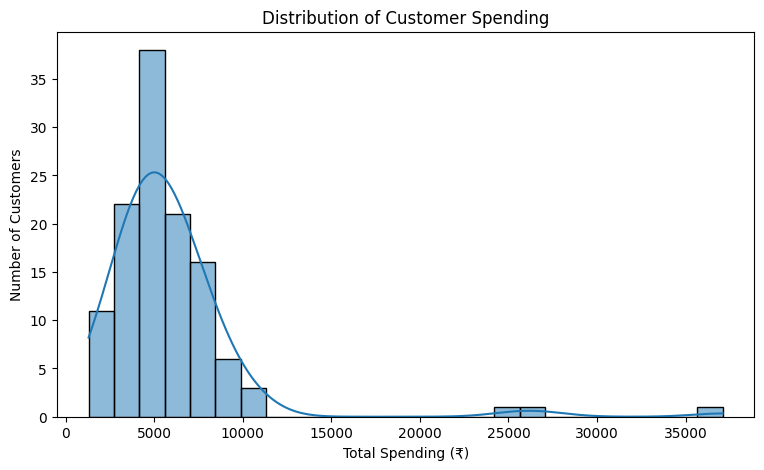

In [17]:

plt.figure(figsize=(9, 5))
sns.histplot(df["Total_Spending"], bins=25, kde=True)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending (₹)")
plt.ylabel("Number of Customers")
plt.show()



### What should you look for?

Ask to identify:

- Where most observations are located
- Whether the distribution is symmetric or skewed
- Whether there are unusually high values
- Whether the mean might be pulled by extreme observations


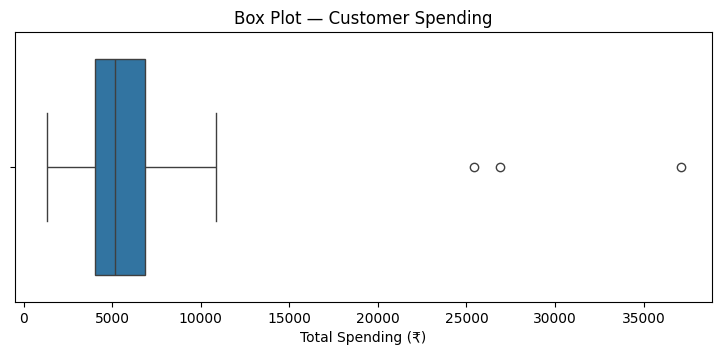

In [18]:

plt.figure(figsize=(9, 3.5))
sns.boxplot(x=df["Total_Spending"])
plt.title("Box Plot — Customer Spending")
plt.xlabel("Total Spending (₹)")
plt.show()



### Box plot interpretation

- Center line → median
- Box → middle 50% (Q1 to Q3)
- Whiskers → typical range under the plotting rule
- Individual points beyond whiskers → possible outliers



# Part E — The Easy Way with Pandas

For a numerical column, pandas can produce a complete statistical summary with:

```python
df["column"].describe()
```


In [19]:

df["Total_Spending"].describe()


,Total_Spending
count,120.00
mean,"5,938.93"
std,"4,414.39"
min,"1,299.00"
25%,"4,059.00"
50%,"5,157.00"
75%,"6,871.00"
max,"37,096.00"



# Part F — Final Mini Challenge

## Business Problem

You are a junior data analyst for an e-commerce company.

The manager asks:

> **"Who is a typical customer, how much do they spend, and are there any unusual customers we should investigate?"**

### Your task

Use the dataset and create a short statistical profile containing:

1. Mean spending
2. Median spending
3. Standard deviation
4. Q1 and Q3
5. IQR
6. Minimum and maximum
7. Number of possible outliers
8. One histogram
9. One box plot

### Final interpretation

Write 4–5 sentences answering:

- What is a typical spending level?
- Is the mean or median more useful here?
- Is spending highly variable?
- Are there possible outliers?
- What should the business investigate next?

**Do not just print the numbers. Explain them.**


In [21]:
spending = df["Total_Spending"]

summary = {
    "Mean": spending.mean(),
    "Median": spending.median(),
    "Std Dev": spending.std(),
    "Q1": spending.quantile(0.25),
    "Q3": spending.quantile(0.75),
    "IQR": spending.quantile(0.75) - spending.quantile(0.25),
    "Min": spending.min(),
    "Max": spending.max()
}

summary


{'Mean': np.float64(5938.933333333333),
 'Median': 5157.0,
 'Std Dev': 4414.386954084582,
 'Q1': np.float64(4059.0),
 'Q3': np.float64(6871.0),
 'IQR': np.float64(2812.0),
 'Min': 1299.0,
 'Max': 37096.0}

In [22]:


Q1 = spending.quantile(0.25)
Q3 = spending.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

possible_outliers = spending[(spending < lower) | (spending > upper)]

print("Possible outliers:", len(possible_outliers))
print(possible_outliers.sort_values(ascending=False).head(10))


Possible outliers: 3
10   37,096.00
90   26,892.00
45   25,450.00
Name: Total_Spending, dtype: float64



# 60-Second Recap

### Descriptive statistics = summarize + understand the data

**Central tendency**
- Mean
- Median
- Mode

**Spread**
- Range
- Variance
- Standard deviation
- IQR

**Distribution**
- Percentiles
- Quartiles
- Histograms
- Box plots
- Outliers

### The key mindset

> **Don't stop at "What is the number?"**
>
> Ask:
>
> **"What does this number tell me about the real-world data?"**

### ML connection

Descriptive statistics is one of the first steps in **Exploratory Data Analysis (EDA)**. It helps us understand distributions, detect outliers, compare features and decide what preprocessing may be needed before machine learning.
